Conor Murray


Question 1: Cross Validation

In [4]:
import numpy as np
import pandas as pd
from sklearn import tree
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

In [23]:
def cross_validation(X, y, k, model):
    m = len(X)
    if k < 2 or k > m:
        print("k must be between 2 and", m)
        return None
    shuffled_positions = np.random.permutation(m)
    X = X.iloc[shuffled_positions]
    y = y.iloc[shuffled_positions]
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    fold_size = m // k
    fold_ids = []
    for i in range(m):
        fold = i // fold_size
        if fold > k - 1:
            fold = k - 1          
        fold_ids.append(fold)
    fold_ids = np.array(fold_ids)
    scores = []
    for i in range(k):
        test_mask = fold_ids == i
        train_mask = fold_ids != i
        X_train = X[train_mask]
        y_train = y[train_mask]
        X_test = X[test_mask]
        y_test = y[test_mask]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        scores.append(acc)
        print("Fold", i + 1, "- test size:", len(X_test), "- accuracy:", round(acc, 4))
    total = 0
    for i in range(len(scores)):
        total = total + scores[i]
    cv_accuracy = total / len(scores)
    print("Cross validation accuracy:", round(cv_accuracy, 4))
    return cv_accuracy

In [11]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)
model = tree.DecisionTreeClassifier()
result = cross_validation(X, y, 7, model)

Fold 1 - test size: 21 - accuracy: 1.0
Fold 2 - test size: 21 - accuracy: 1.0
Fold 3 - test size: 21 - accuracy: 0.9524
Fold 4 - test size: 21 - accuracy: 0.9524
Fold 5 - test size: 21 - accuracy: 0.9524
Fold 6 - test size: 21 - accuracy: 0.9524
Fold 7 - test size: 24 - accuracy: 0.9167
Cross validation accuracy: 0.9609


Question 2: ROC Curve

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("roc_curve_data.csv")
probs = df["Pred_Prob_1"]
actual = df["Actual_Label"]
cutoffs = []
for i in range(1001):
    cutoffs.append(i / 1000)
tpr_list = []
fpr_list = []
for c in cutoffs:
    tp = 0
    fp = 0
    tn = 0
    fn = 0
    for i in range(len(probs)):
        if probs[i] >= c:
            pred = 1
        else:
            pred = 0
        if pred == 1 and actual[i] == 1:
            tp = tp + 1
        elif pred == 1 and actual[i] == 0:
            fp = fp + 1
        elif pred == 0 and actual[i] == 0:
            tn = tn + 1
        else:
            fn = fn + 1

    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    tpr_list.append(tpr)
    fpr_list.append(fpr)
print("Number of cutoffs: ", len(cutoffs))
print("First point (cutoff 0.0):  FPR =", fpr_list[0], " TPR =", tpr_list[0])
print("Last point (cutoff 1.0):   FPR =", fpr_list[-1], " TPR =", tpr_list[-1])

Number of cutoffs:  1001
First point (cutoff 0.0):  FPR = 1.0  TPR = 1.0
Last point (cutoff 1.0):   FPR = 0.0  TPR = 0.0


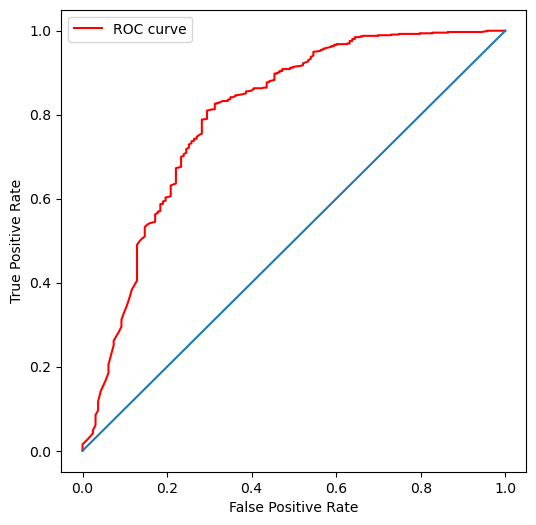

In [35]:
plt.figure(figsize=(6, 6))
plt.plot(fpr_list, tpr_list, color="red", label="ROC curve")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

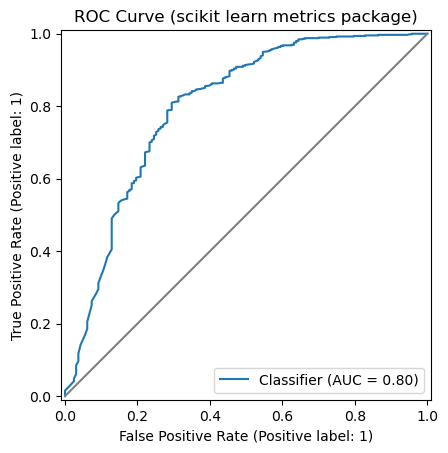

In [33]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(actual, probs)
plt.plot([0, 1], [0, 1], color="gray")
plt.title("ROC Curve (scikit learn metrics package)")
plt.show()